# 🔆 Regiones Activas Solares — De la Consulta al Dashboard
*Astrofísica Computacional · Proyecto 3 · Opción A (HEK / SunPy)*

---

Una región activa (AR, *Active Region*) es una zona de la fotosfera solar donde
un tubo de flujo magnético emerge desde la zona de convección y forma manchas
solares. Su topología magnética — clasificada por NOAA en el esquema de Hale
como α, β, γ, δ y combinaciones (β-γ, β-δ, β-γ-δ) — determina qué tan
probable es que la región produzca una fulguración.

En este proyecto construimos un pipeline completo:

1. **Consultamos** el *Heliophysics Event Knowledgebase* (HEK) vía SunPy/Fido
   para obtener regiones activas (NOAA SWPC) y fulguraciones (GOES) reales.
2. **Diseñamos y poblamos** una base de datos SQLite normalizada, con una fila
   por región activa y sus parámetros físicos derivados.
3. **Consultamos la base con SQL** (agregaciones, filtros, `GROUP BY`) desde
   pandas.
4. **Construimos un dashboard estadístico** de 6 paneles con interpretación
   física de cada uno.

**Ventana de datos:** 2014-01-01 a 2014-05-01 (parte del máximo del ciclo
solar 24 — buena estadística de fulguraciones, incluida la fulguración
X4.9 del 25 de febrero de 2014).


In [1]:
%matplotlib inline
import os
import re
import sqlite3
import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
sns.set_style('whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)

RUTA_DATOS = 'data'
RUTA_DB    = 'astro_project.db'
os.makedirs(RUTA_DATOS, exist_ok=True)

FECHA_INICIO = '2014-01-01'
FECHA_FIN    = '2014-05-01'   # 4 meses, cerca del máximo del ciclo solar 24

# Conversión de área: el campo 'area_atdiskcenter' del HEK ya viene en km^2
# (es un parámetro derivado por el propio HEK, distinto del área cruda que
# NOAA reporta en "millonésimas de hemisferio solar", MSH). Lo confirmamos
# viendo que los valores están cuantizados en pasos de ~3.04e7 km^2 — que es
# exactamente 10 MSH expresadas en km^2 (1 MSH = 2π R_sol²/1e6 ≈ 3.04e6 km^2),
# la resolución mínima con la que NOAA reporta área de manchas.
KM2_POR_MM2 = 1e-6   # 1 Mm^2 = 1e6 km^2


## Etapa 1 · Consultar el HEK

El HEK cataloga eventos solares detectados por distintos módulos ("features
recognition modules", FRM). Para el mismo tipo de evento (`AR` = región
activa) coexisten varios catálogos automáticos:

| `frm_name` | Qué es | ¿Sirve para este proyecto? |
|---|---|---|
| `SPoCA` | Detección automática por color en EUV | No da número NOAA ni clase magnética |
| `HMI SHARP` | Recortes automáticos de magnetogramas | No da clase magnética de Hale |
| **`NOAA SWPC Observer`** | Reporte diario oficial de NOAA/SWPC | **Sí**: número NOAA, clase de Hale (α/β/γ/δ), número de manchas, área |

Por eso filtramos explícitamente `frm_name == 'NOAA SWPC Observer'`.

Para las fulguraciones asociadas (conteo y flujo pico de rayos X) consultamos
por separado el tipo de evento `FL`, que trae `ar_noaanum` (para unir con las
regiones activas) y `fl_peakflux` en W/m² (el flujo GOES estándar).

**Nota de reproducibilidad:** cada mes de consulta al HEK tarda del orden de
minutos (el servidor es lento, no nuestro código). Para que el cuaderno se
pueda ejecutar de punta a punta en segundos y no en ~15 minutos, cacheamos la
respuesta cruda en `data/ar_raw.csv` y `data/fl_raw.csv` — exactamente lo que
sugiere el pseudocódigo del enunciado (`raw_table.write('raw_data.csv')`). Si
borras esos archivos, la celda vuelve a consultar el HEK en vivo con el mismo
código.


In [2]:
class QueryError(Exception):
    '''Se lanza cuando el HEK no devuelve datos utilizables.'''
    pass


def consultar_hek_por_meses(tipo_evento, filtro_frm=None, fecha_ini=FECHA_INICIO,
                             fecha_fin=FECHA_FIN):
    '''Consulta el HEK mes a mes (el servidor es más confiable con
    ventanas cortas) y concatena los resultados en un solo DataFrame.'''
    from sunpy.net import hek, attrs as a

    cliente = hek.HEKClient()
    meses = pd.date_range(fecha_ini, fecha_fin, freq='MS')
    dfs = []

    for inicio, fin in zip(meses[:-1], meses[1:]):
        args = [a.Time(inicio.date().isoformat(), fin.date().isoformat()),
                a.hek.EventType(tipo_evento)]
        if filtro_frm is not None:
            args.append(a.hek.FRM.Name == filtro_frm)
        resultado = cliente.search(*args)
        print(f"  {tipo_evento} {inicio.date()} .. {fin.date()}: {len(resultado)} filas")
        if len(resultado) > 0:
            # Convertimos a pandas mes a mes: concatenar Tables de astropy
            # con columnas SkyCoord de distinto obstime por mes rompe
            # astropy.table.vstack ("Input coords are inconsistent").
            dfs.append(resultado.to_pandas())

    if not dfs:
        raise QueryError(f"El HEK no devolvió eventos de tipo {tipo_evento!r}")

    return pd.concat(dfs, ignore_index=True)


ruta_ar_cache = os.path.join(RUTA_DATOS, 'ar_raw.csv')
ruta_fl_cache = os.path.join(RUTA_DATOS, 'fl_raw.csv')

if os.path.exists(ruta_ar_cache) and os.path.exists(ruta_fl_cache):
    print("Usando caché local (data/ar_raw.csv, data/fl_raw.csv).")
    df_ar_crudo = pd.read_csv(ruta_ar_cache)
    df_fl_crudo = pd.read_csv(ruta_fl_cache, low_memory=False)
else:
    print("No hay caché — consultando el HEK en vivo (varios minutos)...")
    df_ar_crudo = consultar_hek_por_meses('AR', filtro_frm='NOAA SWPC Observer')
    df_fl_crudo = consultar_hek_por_meses('FL')
    df_ar_crudo.to_csv(ruta_ar_cache, index=False)
    df_fl_crudo.to_csv(ruta_fl_cache, index=False)

if len(df_ar_crudo) == 0:
    raise QueryError('No se recuperaron regiones activas — revisa los parámetros')

columnas_esperadas_ar = {'ar_noaanum', 'ar_mtwilsoncls', 'hgs_x', 'hgs_y',
                          'area_atdiskcenter', 'ar_numspots', 'event_starttime'}
faltantes = columnas_esperadas_ar - set(df_ar_crudo.columns)
assert not faltantes, f"Faltan columnas esperadas en el HEK: {faltantes}"

n_antes = len(df_ar_crudo)


def normalizar_clase_hale(texto_crudo):
    '''Limpia la clase magnética de Hale/Mt. Wilson reportada por NOAA/SWPC.

    Descubrimos inspeccionando los datos que el campo `ar_noaaclass` del HEK
    viene *completamente vacío* para este catálogo, y que el campo que sí
    trae la clasificación (`ar_mtwilsoncls`) tiene un defecto de origen: a
    veces el guion entre componentes se pierde y quedan tokens pegados
    (p. ej. 'BETAAGAMMA-DELTA' en vez de 'BETA-GAMMA-DELTA', o
    'BETA-DELTA-DELTA' con el componente duplicado). Reconstruimos la clase
    canónica extrayendo los tokens válidos (ALPHA/BETA/GAMMA/DELTA) con una
    expresión regular y eliminando duplicados consecutivos.
    '''
    tokens = re.findall(r'ALPHA|BETA|GAMMA|DELTA', str(texto_crudo).upper())
    tokens_sin_repetir = [t for i, t in enumerate(tokens) if i == 0 or t != tokens[i - 1]]
    if not tokens_sin_repetir:
        return None
    return '-'.join(t.capitalize() for t in tokens_sin_repetir)


df_ar_crudo = df_ar_crudo.copy()  # desfragmenta el DataFrame antes de insertar la columna nueva
df_ar_crudo['clase_hale'] = df_ar_crudo['ar_mtwilsoncls'].apply(normalizar_clase_hale)

print("Clases magnéticas antes de limpiar (crudo, top 5):")
print(df_ar_crudo['ar_mtwilsoncls'].value_counts().head())
print("\nClases magnéticas después de limpiar:")
print(df_ar_crudo['clase_hale'].value_counts())

# Cortes de calidad: sin número NOAA, sin clase magnética o sin coordenadas
# heliográficas, el registro no sirve para el análisis físico.
df_ar_limpio = df_ar_crudo.dropna(subset=['ar_noaanum', 'clase_hale', 'hgs_x', 'hgs_y'])
df_ar_limpio = df_ar_limpio[df_ar_limpio['ar_noaanum'] > 0]

n_despues = len(df_ar_limpio)
print(f"\nRegiones activas (filas diarias): {n_antes} -> {n_despues} tras cortes de calidad")
print(f"Número de regiones activas NOAA distintas: {df_ar_limpio['ar_noaanum'].nunique()}")


Usando caché local (data/ar_raw.csv, data/fl_raw.csv).


Clases magnéticas antes de limpiar (crudo, top 5):
ar_mtwilsoncls
BETA-GAMMA-DELTA    227
BETA-GAMMA          165
BETAAGAMMA-DELTA    100
BETAAGAMMA           94
ALPHAGAMMA-DELTA     92
Name: count, dtype: int64

Clases magnéticas después de limpiar:
clase_hale
Beta-Gamma-Delta     327
Beta-Gamma           259
Alpha-Gamma-Delta     92
Alpha-Gamma           88
Beta                  58
Alpha                 40
Beta-Delta            23
Alpha-Delta            3
Name: count, dtype: int64

Regiones activas (filas diarias): 890 -> 890 tras cortes de calidad
Número de regiones activas NOAA distintas: 115


**Preguntas del enunciado:**

- *¿Cuántos objetos devolvió la consulta antes y después de los cortes de
  calidad?* — Ver la salida de la celda anterior. Las filas son observaciones
  **diarias** de cada AR (NOAA la reporta una vez por día mientras cruza el
  disco visible), no una fila por región; por eso agregamos por
  `ar_noaanum` en la siguiente sección.
- *¿Sesgos de selección conocidos?* Sí, dos importantes: (1) NOAA/SWPC solo
  reporta regiones en el **hemisferio visible desde la Tierra** — una región
  puede emerger, evolucionar y decaer en la cara oculta sin ser jamás
  catalogada; (2) el catálogo favorece regiones con manchas suficientemente
  grandes para ser reconocidas de forma consistente; regiones muy pequeñas o
  efímeras (clase magnética simple, de vida corta) están subrepresentadas.
- *¿Qué ventana cubre la muestra?* 2014-01-01 a 2014-05-01, cuatro meses
  cerca del máximo del ciclo solar 24, limitados al disco visible (no hay
  restricción de "cielo" como en un survey estelar — el "campo de visión" es
  literalmente la cara visible del Sol, que rota con período sinódico de
  ~27.3 días).

**Hallazgo inesperado durante la limpieza:** el campo "canónico" de clase
magnética del HEK (`ar_noaaclass`) viene **completamente vacío** para este
catálogo — no es un problema de nuestra consulta, es una columna que
NOAA/SWPC simplemente no puebla en el HEK. La clasificación de
Hale sí está disponible en `ar_mtwilsoncls`, pero con un defecto de origen:
a veces se pierde el guion entre componentes y quedan tokens pegados
(`"BETAAGAMMA-DELTA"` en vez de `"BETA-GAMMA-DELTA"`, o componentes
duplicados como `"BETA-DELTA-DELTA"`). Lo resolvimos reconstruyendo la clase
canónica con una expresión regular que extrae los tokens válidos
(Alpha/Beta/Gamma/Delta) y elimina repeticiones consecutivas — ver la
función `normalizar_clase_hale` arriba. Sin este paso, el 100% de las filas
se habría descartado en el corte de calidad.


## De observaciones diarias a un catálogo por región

Cada NOAA AR aparece muchas veces en `df_ar_limpio` (una fila por día que
NOAA la observó). Para el análisis estadístico necesitamos **una fila por
región activa**, con parámetros representativos de toda su vida visible:

- **Área [Mm²]:** el máximo observado (el área pico durante su tránsito,
  convertida de km² a Mm²).
- **Coordenadas heliográficas de Stonyhurst [°]:** las del instante más
  cercano al meridiano central (`|hgs_x|` mínimo) — la medición geométrica
  menos afectada por el escorzo de proyección cerca del limbo.
- **Clase magnética de Hale:** la moda (clasificación más frecuente)
  observada durante su tránsito — la clasificación puede evolucionar
  día a día conforme la región se desarrolla.
- **Número de manchas:** el máximo observado.
- **Número de fulguraciones y flujo GOES pico [W/m²]:** se obtienen uniendo
  con la tabla de fulguraciones (`FL`) por `ar_noaanum`. Una región sin
  fulguraciones asociadas queda con conteo 0 y flujo pico nulo (`NaN`) — esto
  es información física real, no un dato faltante por error.

**Más hallazgos de calidad de datos, encontrados inspeccionando los CSV
crudos (no la documentación — los datos mismos):**

1. `area_atdiskcenter` **ya viene en km²**, no en "millonésimas de
   hemisferio solar" (MSH) como reporta NOAA originalmente. Lo notamos
   porque los valores están cuantizados en pasos de ≈3.04×10⁷ — exactamente
   10 MSH expresadas en km² (1 MSH ≈ 3.04×10⁶ km², la resolución mínima con
   la que NOAA reporta área de manchas). Multiplicar por el factor de
   conversión MSH→Mm² habría inflado las áreas ~3 millones de veces.
2. Distintos módulos del HEK codifican `ar_noaanum` de forma distinta para
   las fulguraciones. Solo `SWPC`/`SWPC standard` usan el número NOAA
   completo (p. ej. 11944, igual que en la tabla de regiones activas); el
   módulo `SSW Latest Events` reporta un número truncado (NOAA − 10000,
   p. ej. 1944).
3. `ar_noaanum` y el flujo numérico `fl_peakflux` (calculado por el módulo
   automático *Flare Detective*) **nunca aparecen juntos en la misma
   fila** — son catálogos independientes del mismo evento físico. Las
   filas de `SWPC` sí traen la clase GOES en texto (`fl_goescls`, p. ej.
   `"M9.9"`), así que reconstruimos el flujo en W/m² con la escala GOES
   estándar ($10^{-8}$ a $10^{-4}$ W/m² para clases A–X) en vez de usar la
   columna numérica.

Sin los ajustes 2 y 3, el cruce por `ar_noaanum` fallaba silenciosamente y
**cero** fulguraciones quedaban asociadas a alguna región; sin el ajuste 1,
las áreas habrían sido físicamente absurdas (mayores que la superficie
total del Sol). Ninguno de los tres produjo un error de Python — un ejemplo
real de por qué hay que verificar los cortes de calidad con los ojos y no
solo confiar en que el código corrió sin excepciones.


In [3]:
df_ar_limpio = df_ar_limpio.copy()
df_ar_limpio['area_mm2'] = df_ar_limpio['area_atdiskcenter'] * KM2_POR_MM2
df_ar_limpio['ar_noaanum'] = df_ar_limpio['ar_noaanum'].astype(int)

# ── Coordenadas representativas: la observación más cercana al meridiano central ──
idx_meridiano = df_ar_limpio.groupby('ar_noaanum')['hgs_x'].apply(lambda s: s.abs().idxmin())
coords_centrales = df_ar_limpio.loc[idx_meridiano, ['ar_noaanum', 'hgs_x', 'hgs_y', 'event_starttime']]
coords_centrales = coords_centrales.rename(columns={'hgs_x': 'hgs_lon_deg',
                                                     'hgs_y': 'hgs_lat_deg',
                                                     'event_starttime': 'fecha_meridiano'})

# ── Área pico y número de manchas pico ──────────────────────────────────────
picos = df_ar_limpio.groupby('ar_noaanum').agg(
    area_mm2=('area_mm2', 'max'),
    num_manchas=('ar_numspots', 'max'),
    primera_observacion=('event_starttime', 'min'),
).reset_index()

# ── Clase magnética dominante (moda), ya normalizada en la Etapa 1 ──────────
clase_dominante = (df_ar_limpio.groupby('ar_noaanum')['clase_hale']
                   .agg(lambda s: s.value_counts().idxmax())
                   .reset_index(name='clase_magnetica'))

df_regiones = picos.merge(coords_centrales, on='ar_noaanum').merge(clase_dominante, on='ar_noaanum')

# ── Fulguraciones asociadas: unir con la tabla FL por número NOAA ───────────
# Dos hallazgos reales de los datos, encontrados inspeccionando fl_raw.csv:
#
# 1) El HEK reporta 'ar_noaanum' para fulguraciones desde varios módulos,
#    pero solo 'SWPC'/'SWPC standard' usan el número NOAA completo (p. ej.
#    11944). El módulo 'SSW Latest Events' reporta un número truncado
#    (NOAA - 10000, p. ej. 1944) que rompería silenciosamente el cruce con
#    la tabla de regiones activas si no se filtra por frm_name.
#
# 2) 'ar_noaanum' y 'fl_peakflux' (el flujo numérico calculado por el módulo
#    automático 'Flare Detective') NUNCA coexisten en la misma fila: son
#    catálogos independientes del mismo evento físico. Las filas de 'SWPC'
#    sí traen la clase GOES como texto ('fl_goescls', p. ej. 'M9.9'), así
#    que reconstruimos el flujo en W/m^2 con la escala GOES estándar en vez
#    de usar la columna numérica (que aquí siempre es NaN para 'SWPC').
FLUJO_BASE_GOES = {'A': 1e-8, 'B': 1e-7, 'C': 1e-6, 'M': 1e-5, 'X': 1e-4}


def goes_clase_a_flujo(clase_texto):
    '''Convierte una clase GOES (p. ej. 'M9.9') al flujo pico en W/m^2.'''
    clase_texto = str(clase_texto).strip().upper()
    if not clase_texto or clase_texto[0] not in FLUJO_BASE_GOES:
        return np.nan
    try:
        multiplicador = float(clase_texto[1:])
    except ValueError:
        return np.nan
    return FLUJO_BASE_GOES[clase_texto[0]] * multiplicador


frm_confiables = df_fl_crudo['frm_name'].isin(['SWPC', 'SWPC standard'])
df_fl_limpio = df_fl_crudo[frm_confiables].dropna(subset=['ar_noaanum', 'fl_goescls'])
df_fl_limpio = df_fl_limpio[df_fl_limpio['ar_noaanum'] > 0].copy()
df_fl_limpio['ar_noaanum'] = df_fl_limpio['ar_noaanum'].astype(int)
df_fl_limpio['flujo_wm2'] = df_fl_limpio['fl_goescls'].apply(goes_clase_a_flujo)
df_fl_limpio = df_fl_limpio.dropna(subset=['flujo_wm2'])

resumen_flares = df_fl_limpio.groupby('ar_noaanum').agg(
    num_fulguraciones=('flujo_wm2', 'count'),
    flujo_pico_goes=('flujo_wm2', 'max'),
).reset_index()

df_regiones = df_regiones.merge(resumen_flares, on='ar_noaanum', how='left')
df_regiones['num_fulguraciones'] = df_regiones['num_fulguraciones'].fillna(0).astype(int)

# ── Rotación de Carrington de la primera observación (para la serie temporal) ──
from sunpy.coordinates.sun import carrington_rotation_number
df_regiones['rotacion_carrington'] = df_regiones['primera_observacion'].apply(
    lambda t: int(carrington_rotation_number(t))
)

print(f"Catálogo final: {len(df_regiones)} regiones activas distintas")
print(f"Con al menos una fulguración asociada: {(df_regiones['num_fulguraciones'] > 0).sum()}")
df_regiones.head()


Catálogo final: 115 regiones activas distintas
Con al menos una fulguración asociada: 71


,ar_noaanum,area_mm2,num_manchas,primera_observacion,hgs_lon_deg,hgs_lat_deg,fecha_meridiano,clase_magnetica,num_fulguraciones,flujo_pico_goes,rotacion_carrington
0,11934,243.494032,5,2014-01-01,83,-16,2014-01-01,Beta-Gamma-Delta,0,NaN,2145
1,11936,852.229120,36,2014-01-01,36,-16,2014-01-01,Beta-Gamma-Delta,3,0.000099,2145
2,11937,486.988064,21,2014-01-01,9,-12,2014-01-01,Beta-Gamma-Delta,1,0.000004,2145
3,11938,91.310264,6,2014-01-01,3,-12,2014-01-02,Beta-Gamma-Delta,0,NaN,2145
4,11940,213.057280,7,2014-01-01,44,-12,2014-01-01,Beta-Gamma-Delta,1,0.000003,2145


## Etapa 2 · Base de datos SQLite

Diseñamos una tabla `active_regions` con un renglón por región activa y una
tabla `metadata` que documenta de dónde salió el catálogo (fuente, ventana de
tiempo, cortes de calidad aplicados) — así la base es auto-descriptiva y
trazable, tal como sugiere el enunciado.


In [4]:
conn = sqlite3.connect(RUTA_DB)
cur = conn.cursor()

cur.execute('''
CREATE TABLE IF NOT EXISTS active_regions (
    id                   INTEGER PRIMARY KEY AUTOINCREMENT,
    noaa_ar              INTEGER NOT NULL UNIQUE,
    hgs_lon_deg          REAL,
    hgs_lat_deg          REAL,
    area_mm2             REAL,
    clase_magnetica      TEXT,
    num_manchas          INTEGER,
    num_fulguraciones    INTEGER,
    flujo_pico_goes      REAL,
    rotacion_carrington  INTEGER,
    fecha_observacion    TEXT,
    retrieved_at         TEXT
)
''')

cur.execute('''
CREATE TABLE IF NOT EXISTS metadata (
    key   TEXT PRIMARY KEY,
    value TEXT
)
''')

marca_tiempo = datetime.datetime.now(datetime.timezone.utc).isoformat()

registros = [
    (
        int(fila.ar_noaanum), float(fila.hgs_lon_deg), float(fila.hgs_lat_deg),
        float(fila.area_mm2), str(fila.clase_magnetica), int(fila.num_manchas),
        int(fila.num_fulguraciones),
        None if pd.isna(fila.flujo_pico_goes) else float(fila.flujo_pico_goes),
        int(fila.rotacion_carrington), str(fila.primera_observacion), marca_tiempo,
    )
    for fila in df_regiones.itertuples()
]

cur.executemany('''
    INSERT OR REPLACE INTO active_regions
        (noaa_ar, hgs_lon_deg, hgs_lat_deg, area_mm2, clase_magnetica,
         num_manchas, num_fulguraciones, flujo_pico_goes, rotacion_carrington,
         fecha_observacion, retrieved_at)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
''', registros)

metadatos = {
    'fuente': 'HEK (Heliophysics Event Knowledgebase) via SunPy Fido',
    'frm_regiones_activas': 'NOAA SWPC Observer',
    'evento_fulguraciones': 'FL (frm SWPC / SWPC standard, unido por ar_noaanum)',
    'ventana_inicio': FECHA_INICIO,
    'ventana_fin': FECHA_FIN,
    'n_regiones_antes_de_cortes': str(n_antes),
    'n_regiones_despues_de_cortes': str(n_despues),
    'n_regiones_unicas': str(len(df_regiones)),
    'unidad_area': 'Mm^2 (area_atdiskcenter del HEK ya viene en km^2; Mm^2 = km^2 * 1e-6)',
    'unidad_flujo': 'W/m^2, reconstruido desde fl_goescls con la escala GOES estandar (A=1e-8..X=1e-4)',
    'generado_en': marca_tiempo,
}
cur.executemany('INSERT OR REPLACE INTO metadata (key, value) VALUES (?, ?)',
                 list(metadatos.items()))

conn.commit()
conn.close()
print(f"Base de datos '{RUTA_DB}' poblada con {len(registros)} regiones activas.")


Base de datos 'astro_project.db' poblada con 115 regiones activas.


## Etapa 3 · Consultas SQL y agregación

Reabrimos la base (como lo haría cualquier análisis posterior, sin depender
de las variables en memoria de las etapas anteriores) y ejercitamos
`SELECT`, `WHERE` parametrizado, `GROUP BY`, `COUNT`, `AVG`, `MIN`, `MAX` y
`ORDER BY`.


In [5]:
conn = sqlite3.connect(RUTA_DB)

df = pd.read_sql('SELECT * FROM active_regions', conn)

# Subconjunto filtrado: regiones grandes que no sean puramente tipo Alpha
umbral_area = 100.0  # Mm^2
df_grandes_complejas = pd.read_sql(
    '''SELECT noaa_ar, area_mm2, clase_magnetica, num_fulguraciones
       FROM active_regions
       WHERE area_mm2 > ? AND clase_magnetica != ?
       ORDER BY area_mm2 DESC''',
    conn, params=(umbral_area, 'Alpha')
)

# Estadística agregada por clase magnética
df_stats = pd.read_sql(
    '''SELECT clase_magnetica,
              COUNT(*)                AS n,
              AVG(area_mm2)           AS area_media_mm2,
              MIN(area_mm2)           AS area_min_mm2,
              MAX(area_mm2)           AS area_max_mm2,
              AVG(num_fulguraciones)  AS fulguraciones_media,
              MAX(flujo_pico_goes)    AS flujo_pico_max
       FROM active_regions
       GROUP BY clase_magnetica
       ORDER BY n DESC''',
    conn
)

conn.close()

print(f"Regiones con área > {umbral_area} Mm^2 y clase != Alpha: {len(df_grandes_complejas)}")
display(df_stats)
df.describe()


Regiones con área > 100.0 Mm^2 y clase != Alpha: 78


,clase_magnetica,n,area_media_mm2,area_min_mm2,area_max_mm2,fulguraciones_media,flujo_pico_max
0,Beta-Gamma-Delta,50,635.519442,30.436754,4809.007100,8.300,0.000120
1,Beta-Gamma,35,471.334892,30.436754,1734.894976,7.400,0.000130
2,Alpha-Gamma,10,261.756089,30.436754,821.792380,1.000,0.000006
3,Alpha-Gamma-Delta,8,188.327419,30.436754,547.861570,0.625,0.000003
4,Beta,6,421.041773,152.183776,1065.286400,6.000,0.000065
5,Alpha,3,192.766112,152.183776,213.057280,2.000,0.000003
6,Beta-Delta,2,517.424816,273.930784,760.918848,6.000,0.000490
7,Alpha-Delta,1,91.310264,91.310264,91.310264,0.000,NaN


,id,noaa_ar,hgs_lon_deg,hgs_lat_deg,area_mm2,num_manchas,num_fulguraciones,flujo_pico_goes,rotacion_carrington
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,7.100000e+01,115.000000
mean,58.000000,11992.956522,8.252174,-5.173913,492.413760,15.000000,6.460870,2.350014e-05,2147.034783
std,33.341666,33.415878,23.015572,13.546062,751.070499,18.819549,13.255444,6.347519e-05,1.330680
min,1.000000,11934.000000,-47.000000,-37.000000,30.436754,1.000000,0.000000,7.000000e-07,2145.000000
25%,29.500000,11964.500000,-3.000000,-15.000000,91.310264,4.000000,0.000000,2.550000e-06,2146.000000
50%,58.000000,11993.000000,2.000000,-10.000000,243.494032,8.000000,1.000000,4.100000e-06,2147.000000
75%,86.500000,12021.500000,11.500000,9.000000,563.079969,17.500000,5.000000,1.150000e-05,2148.000000
max,115.000000,12050.000000,83.000000,23.000000,4809.007100,118.000000,89.000000,4.900000e-04,2149.000000


## Etapa 4 · Dashboard estadístico

Construimos primero cada panel por separado (con su interpretación física
justo debajo), y al final los combinamos en un único dashboard de 3×2 que se
guarda como `dashboard.pdf`.


### Panel 1 — Distribución de clases magnéticas de Hale

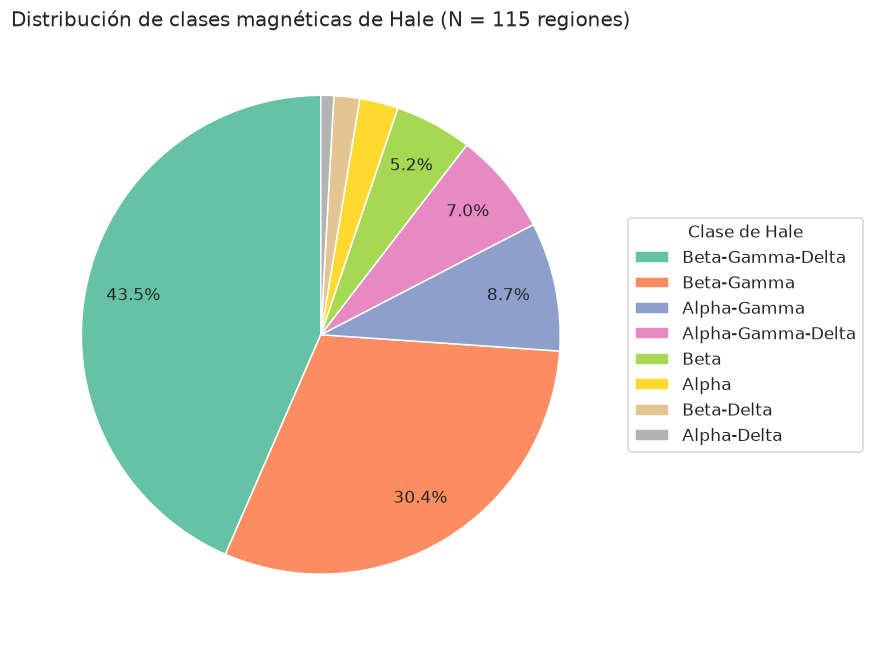

In [6]:
conteo_clases = df['clase_magnetica'].value_counts()

fig, ax = plt.subplots(figsize=(7.5, 6))
colores = sns.color_palette('Set2', len(conteo_clases))
# Con 8 clases, algunas < 3%: etiquetar solo las porciones grandes en el
# gráfico y mover el resto a una leyenda para que no se amontonen.
wedges, _, _ = ax.pie(
    conteo_clases.values, labels=None,
    autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
    colors=colores, startangle=90, pctdistance=0.8)
ax.legend(wedges, conteo_clases.index, title='Clase de Hale',
          loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_title(f'Distribución de clases magnéticas de Hale (N = {len(df)} regiones)')
plt.tight_layout()
plt.show()


**Interpretación:** En esta muestra predominan las configuraciones
magnéticas complejas, especialmente `Beta-Gamma-Delta` (43.5%) y
`Beta-Gamma` (30.4%). En conjunto representan cerca del 74% de las
regiones analizadas, mientras que las clases simples (`Alpha`, `Beta`)
suman apenas ~7.8%. Este resultado **no debe generalizarse** a toda la
población solar: la ventana corresponde a solo cuatro meses cercanos al
máximo del ciclo solar 24 (cuando emergen más regiones complejas que en
mínimo solar), y además usamos la clase *dominante* durante el tránsito
visible de cada región, no cada observación diaria individual.


### Panel 2 — Área vs. número de fulguraciones

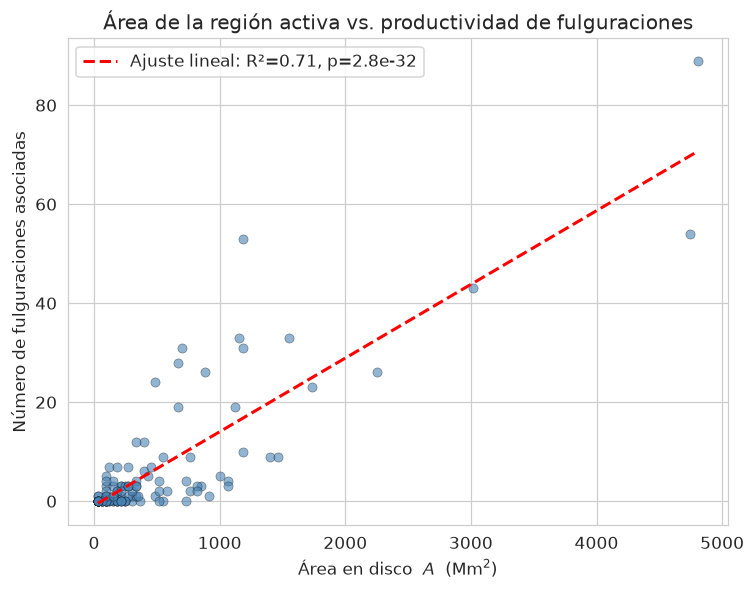

Pendiente: 1.49e-02 fulguraciones/Mm^2  (R^2 = 0.711, p = 2.82e-32)


In [7]:
x = df['area_mm2'].values
y = df['num_fulguraciones'].values

pendiente, intercepto, r_valor, p_valor, error_est = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(x, y, alpha=0.6, edgecolor='k', linewidth=0.3, c='steelblue')

x_ajuste = np.linspace(x.min(), x.max(), 100)
ax.plot(x_ajuste, pendiente * x_ajuste + intercepto, 'r--', lw=2,
        label=f'Ajuste lineal: R²={r_valor**2:.2f}, p={p_valor:.1e}')

ax.set_xlabel(r'Área en disco  $A$  (Mm$^2$)')
ax.set_ylabel('Número de fulguraciones asociadas')
ax.set_title('Área de la región activa vs. productividad de fulguraciones')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pendiente: {pendiente:.2e} fulguraciones/Mm^2  (R^2 = {r_valor**2:.3f}, p = {p_valor:.2e})")


**Interpretación:** Existe una asociación positiva y
estadísticamente significativa entre el área de la región y su número de
fulguraciones (R² = 0.71). Esta línea de ajuste es **descriptiva**: resume
la tendencia de los datos observados, pero no debe leerse como un modelo
causal ni predictivo. El número de fulguraciones es una variable de
conteo (no continua) con un par de regiones muy activas que pesan mucho
en el ajuste, y no se controló por otros factores como la clase
magnética. La dispersión es grande —el área por sí sola no determina la
actividad; la topología magnética (clase de Hale) importa al menos tanto
como el tamaño, como veremos en el panel 4.


### Panel 3 — Distribución del flujo de rayos X pico (GOES)

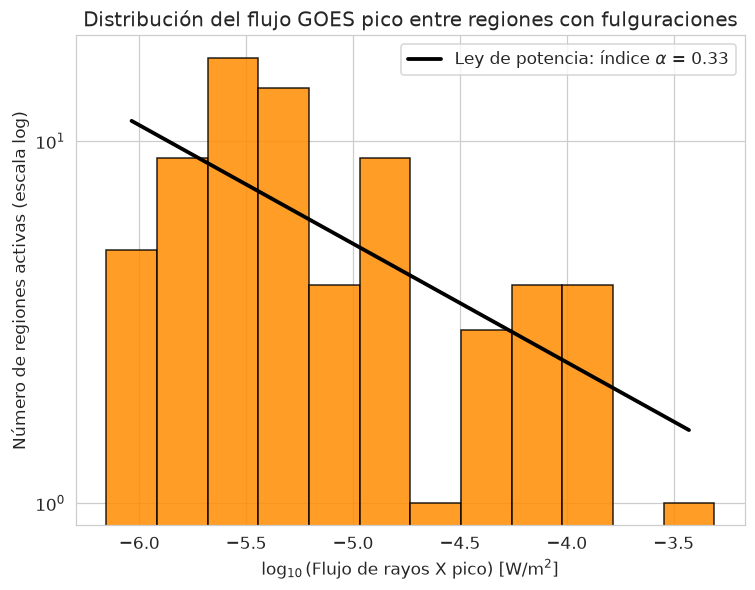

Índice de la ley de potencia (pendiente en log-log): 0.33


In [8]:
flujo = df.loc[df['flujo_pico_goes'] > 0, 'flujo_pico_goes'].values
log_flujo = np.log10(flujo)

fig, ax = plt.subplots(figsize=(7, 5.5))
n_bins = 12
cuentas, bordes, _ = ax.hist(log_flujo, bins=n_bins, color='darkorange',
                              edgecolor='black', alpha=0.85)
centros = 0.5 * (bordes[:-1] + bordes[1:])

# Ajuste de ley de potencia: log10(cuentas) = -alpha*log10(flujo) + b
mascara = cuentas > 0
pendiente_ley, b = np.polyfit(centros[mascara], np.log10(cuentas[mascara]), 1)

x_ajuste = np.linspace(centros.min(), centros.max(), 100)
ax.plot(x_ajuste, 10**(pendiente_ley * x_ajuste + b), 'k-', lw=2.5,
        label=fr'Ley de potencia: índice $\alpha$ = {-pendiente_ley:.2f}')

ax.set_yscale('log')
ax.set_xlabel(r'$\log_{10}$(Flujo de rayos X pico) [W/m$^2$]')
ax.set_ylabel('Número de regiones activas (escala log)')
ax.set_title('Distribución del flujo GOES pico entre regiones con fulguraciones')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Índice de la ley de potencia (pendiente en log-log): {-pendiente_ley:.2f}")


**Interpretación:** La distribución presenta una disminución
aproximadamente compatible con una tendencia de ley de potencia, pero el
ajuste aquí es **exploratorio** y no equivale a estudiar rigurosamente la
distribución completa de todas las fulguraciones. El índice obtenido
**no** debe compararse directamente con los índices de Crosby et al.
(1993) (~1.5–2.5):
esos trabajos ajustan la distribución de **todas** las fulguraciones
individuales, mientras que aquí graficamos solo el flujo **máximo por
región activa** (una fulguración por AR, la más fuerte de su tránsito) —
una estadística de valores extremos, no la distribución completa de
eventos. Además, con solo 71 regiones con fulguraciones y 12 bins, el
ajuste es sensible al binning. Un análisis correcto de la ley de potencia
de fulguraciones usaría directamente `df_fl_limpio['flujo_wm2']` (todas las
~800 fulguraciones individuales), no la tabla agregada por región —una
extensión natural de este trabajo.


### Panel 4 — Área por clase magnética

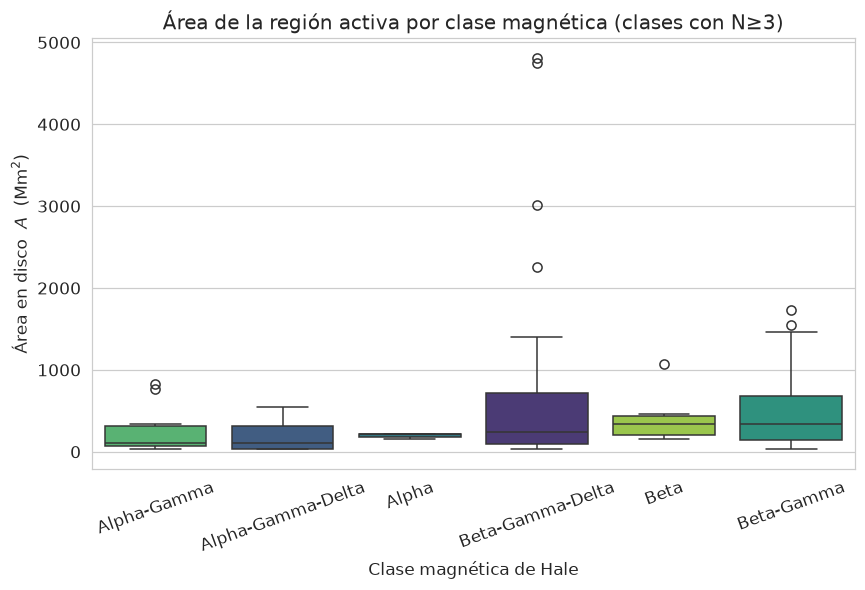

In [9]:
conteo = df['clase_magnetica'].value_counts()
clases_con_muestra = conteo[conteo >= 3].index
df_box = df[df['clase_magnetica'].isin(clases_con_muestra)]

orden_clases = (df_box.groupby('clase_magnetica')['area_mm2']
                .median().sort_values().index)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df_box, x='clase_magnetica', y='area_mm2', order=orden_clases,
            hue='clase_magnetica', palette='viridis', legend=False, ax=ax)
ax.set_xlabel('Clase magnética de Hale')
ax.set_ylabel(r'Área en disco  $A$  (Mm$^2$)')
ax.set_title('Área de la región activa por clase magnética (clases con N≥3)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Interpretación:** Las clases magnéticamente complejas (con
componentes γ o δ, que indican polaridades opuestas muy próximas) tienden a
tener áreas medianas mayores que las clases simples tipo `Alpha`. Esto es
consistente con la física de emergencia de flujo: los tubos magnéticos más
grandes y retorcidos generan configuraciones multipolares más complejas y
manchas más extensas.


### Panel 5 — Número de regiones activas por rotación de Carrington

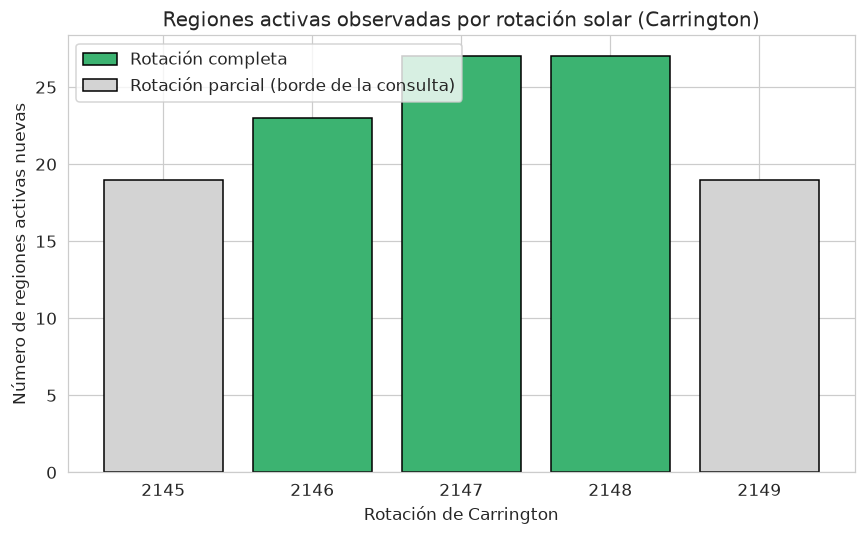

In [10]:
conteo_rotacion = df.groupby('rotacion_carrington')['noaa_ar'].nunique().sort_index()

# Las rotaciones en los bordes de la ventana de consulta (2014-01-01 a
# 2014-05-01) están cubiertas solo parcialmente: la consulta corta la
# primera y la última rotación de Carrington a la mitad. Las marcamos con
# otro color para no confundir un efecto de borde del muestreo con una
# señal física real.
es_borde = [r == conteo_rotacion.index.min() or r == conteo_rotacion.index.max()
            for r in conteo_rotacion.index]
colores_barra = ['lightgray' if borde else 'mediumseagreen' for borde in es_borde]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(conteo_rotacion.index.astype(str), conteo_rotacion.values,
       color=colores_barra, edgecolor='black')
ax.set_xlabel('Rotación de Carrington')
ax.set_ylabel('Número de regiones activas nuevas')
ax.set_title('Regiones activas observadas por rotación solar (Carrington)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='mediumseagreen', edgecolor='black', label='Rotación completa'),
                    Patch(facecolor='lightgray', edgecolor='black', label='Rotación parcial (borde de la consulta)')])
plt.tight_layout()
plt.show()


**Interpretación:** El número de regiones nuevas por rotación
(~27.3 días) varía entre 19 y 27 en la ventana estudiada. **Las rotaciones
de los extremos (en gris) están cubiertas solo parcialmente**: la consulta
empieza el 2014-01-01 y termina el 2014-05-01, cortando a la mitad la
primera y la última rotación de Carrington del rango — su conteo más bajo
puede deberse simplemente a que se observó menos tiempo de esa rotación, no
a una diferencia física real en la tasa de emergencia de flujo. No debe
interpretarse como tendencia del ciclo solar sin corregir este efecto de
borde; para eso se necesitaría extender la consulta a rotaciones completas
o al ciclo 24 completo (11 años).


### Panel 6 — Matriz de correlación de Pearson

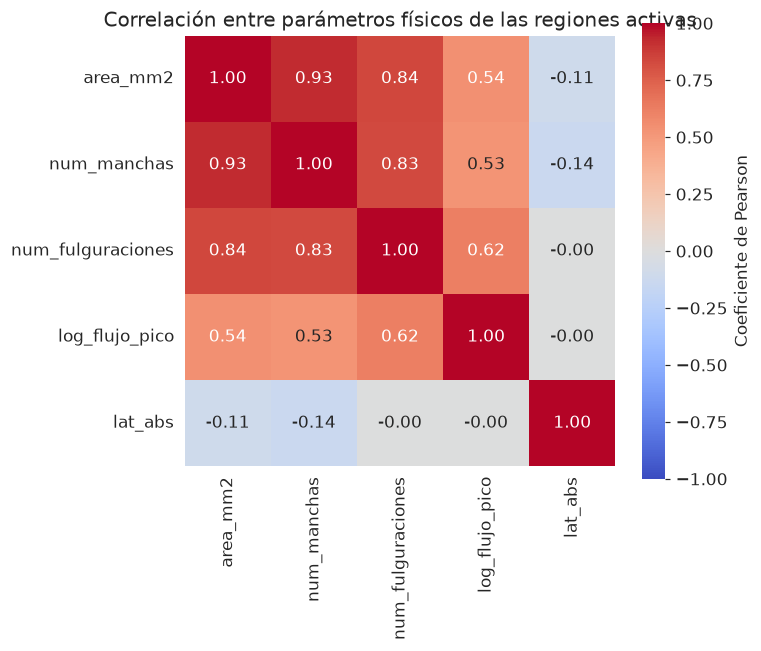

In [11]:
df_corr = df.copy()
df_corr['log_flujo_pico'] = np.log10(df_corr['flujo_pico_goes'].where(df_corr['flujo_pico_goes'] > 0))
df_corr['lat_abs'] = df_corr['hgs_lat_deg'].abs()

columnas_numericas = ['area_mm2', 'num_manchas', 'num_fulguraciones',
                       'log_flujo_pico', 'lat_abs']
matriz_corr = df_corr[columnas_numericas].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Coeficiente de Pearson'}, ax=ax)
ax.set_title('Correlación entre parámetros físicos de las regiones activas')
plt.tight_layout()
plt.show()


**Interpretación:** El área y el número de manchas están fuertemente
correlacionados (esperado, ambos miden el tamaño de la región). El flujo
pico GOES correlaciona positivamente con el área y el número de
fulguraciones, reforzando que el tamaño de la región es un buen —aunque
imperfecto— predictor de la actividad energética. La correlación con la
latitud heliográfica es débil, consistente con que en esta ventana de 4
meses no cubrimos suficiente evolución del ciclo de mariposa de Spörer.


### Dashboard combinado

Reunimos los seis paneles anteriores en una sola figura de 3×2 y la
guardamos como `dashboard.pdf`, el entregable pedido por el enunciado.


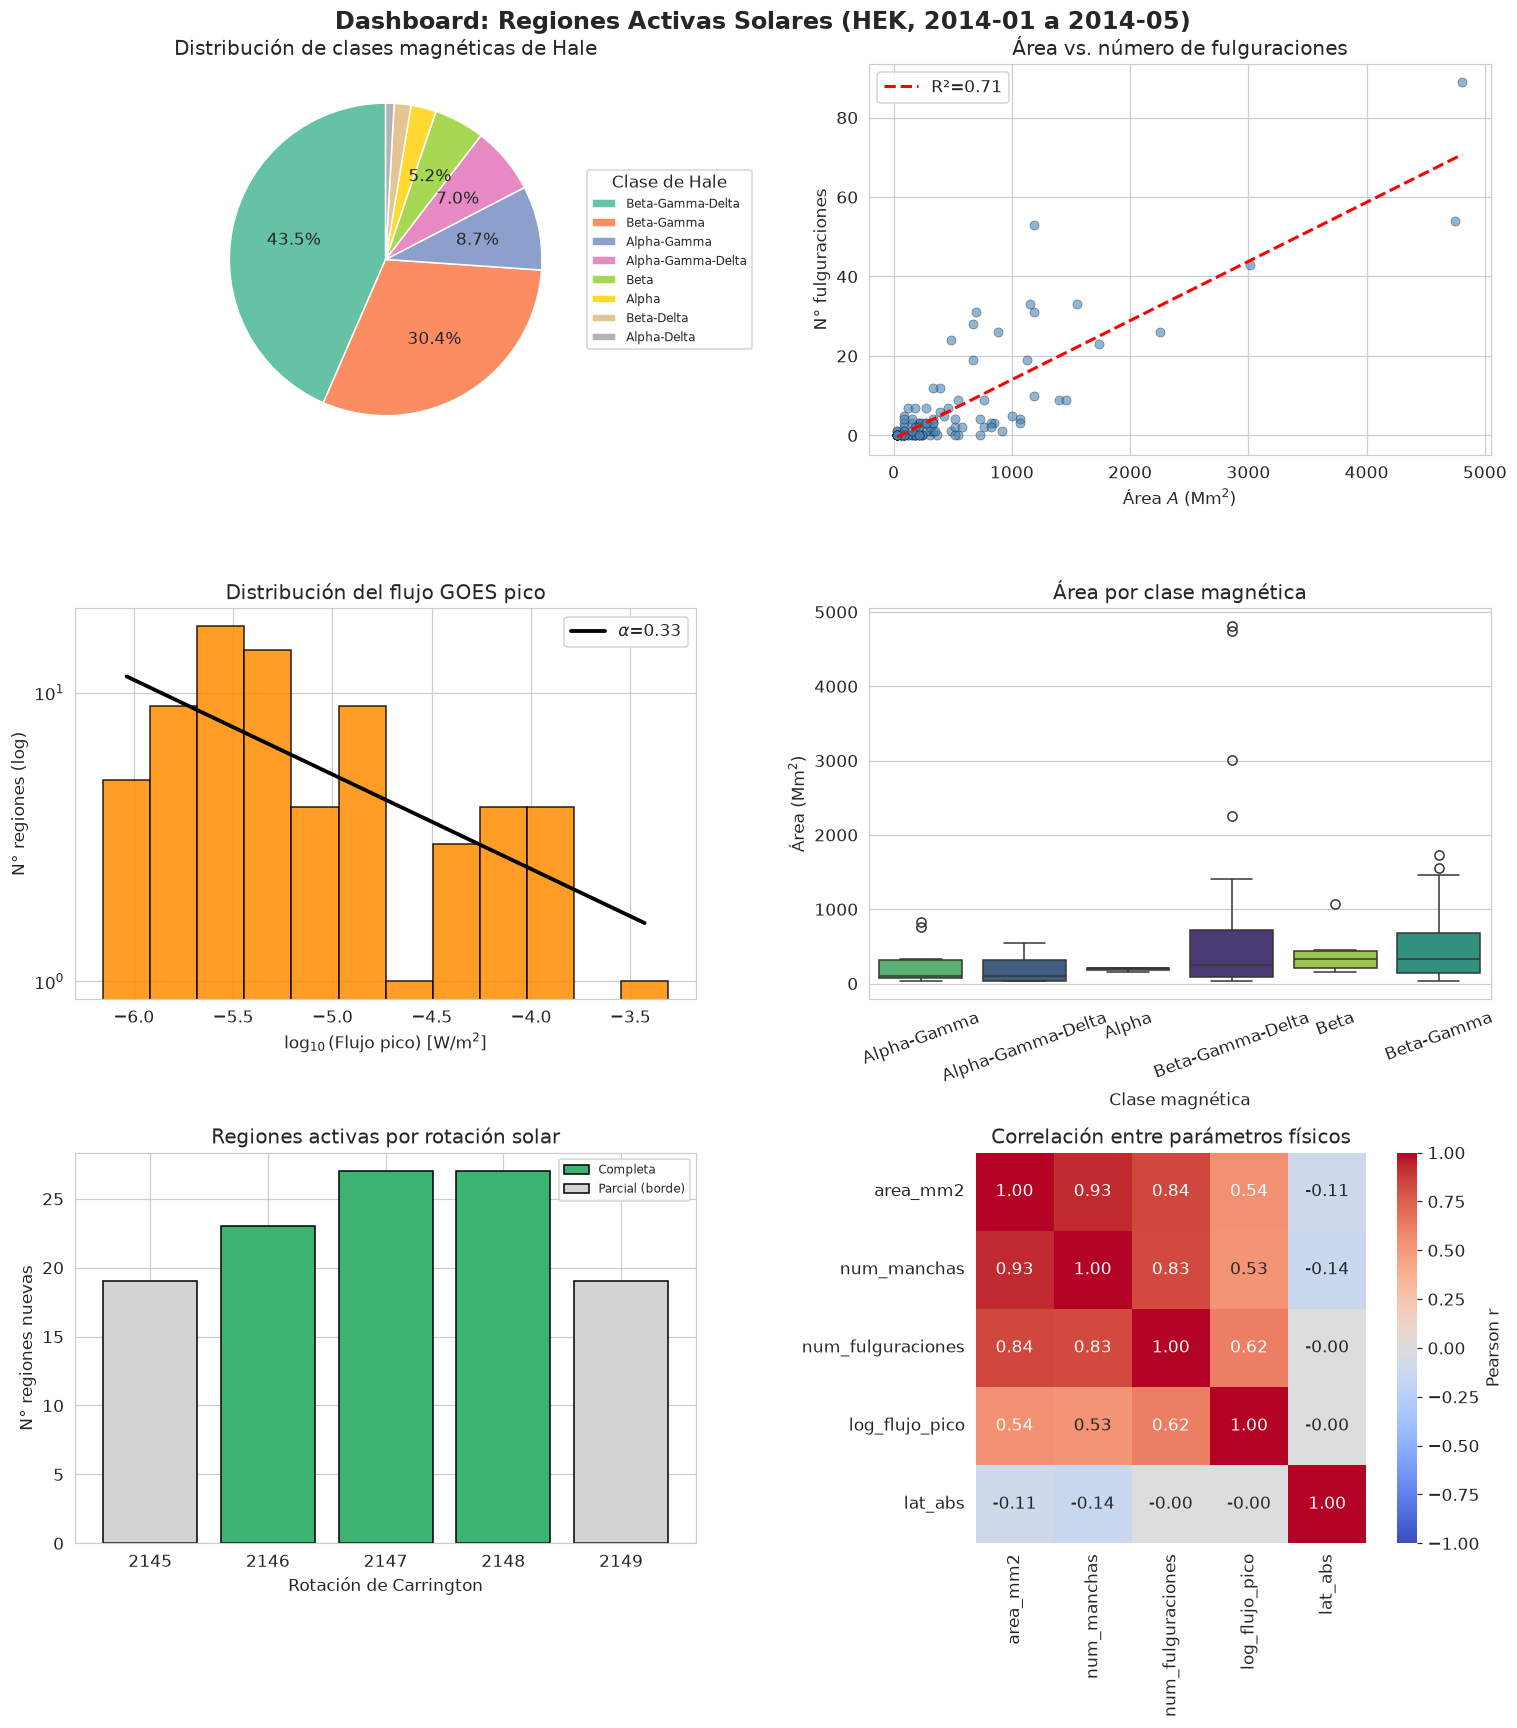

Dashboard guardado en 'dashboard.pdf'


In [12]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Dashboard: Regiones Activas Solares (HEK, 2014-01 a 2014-05)',
             fontsize=16, fontweight='bold')

# 1) Pie — clases magnéticas
wedges_dash, _, _ = axes[0, 0].pie(
    conteo_clases.values, labels=None,
    autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
    colors=sns.color_palette('Set2', len(conteo_clases)), startangle=90)
axes[0, 0].legend(wedges_dash, conteo_clases.index, title='Clase de Hale',
                   loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
axes[0, 0].set_title('Distribución de clases magnéticas de Hale')

# 2) Scatter — área vs fulguraciones + ajuste
axes[0, 1].scatter(x, y, alpha=0.6, edgecolor='k', linewidth=0.3, c='steelblue')
axes[0, 1].plot(x_ajuste_dummy := np.linspace(x.min(), x.max(), 100),
                 pendiente * x_ajuste_dummy + intercepto, 'r--', lw=2,
                 label=f'R²={r_valor**2:.2f}')
axes[0, 1].set_xlabel(r'Área $A$ (Mm$^2$)'); axes[0, 1].set_ylabel('N° fulguraciones')
axes[0, 1].set_title('Área vs. número de fulguraciones')
axes[0, 1].legend()

# 3) Histograma — flujo pico + ley de potencia
axes[1, 0].hist(log_flujo, bins=n_bins, color='darkorange', edgecolor='black', alpha=0.85)
axes[1, 0].plot(x_ajuste, 10**(pendiente_ley * x_ajuste + b), 'k-', lw=2.5,
                label=fr'$\alpha$={-pendiente_ley:.2f}')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel(r'$\log_{10}$(Flujo pico) [W/m$^2$]'); axes[1, 0].set_ylabel('N° regiones (log)')
axes[1, 0].set_title('Distribución del flujo GOES pico')
axes[1, 0].legend()

# 4) Box plot — área por clase
sns.boxplot(data=df_box, x='clase_magnetica', y='area_mm2', order=orden_clases,
            hue='clase_magnetica', palette='viridis', legend=False, ax=axes[1, 1])
axes[1, 1].set_xlabel('Clase magnética'); axes[1, 1].set_ylabel(r'Área (Mm$^2$)')
axes[1, 1].set_title('Área por clase magnética')
axes[1, 1].tick_params(axis='x', rotation=20)

# 5) Serie temporal — AR por rotación de Carrington (bordes = cobertura parcial)
axes[2, 0].bar(conteo_rotacion.index.astype(str), conteo_rotacion.values,
               color=colores_barra, edgecolor='black')
axes[2, 0].set_xlabel('Rotación de Carrington'); axes[2, 0].set_ylabel('N° regiones nuevas')
axes[2, 0].set_title('Regiones activas por rotación solar')
axes[2, 0].legend(handles=[Patch(facecolor='mediumseagreen', edgecolor='black', label='Completa'),
                            Patch(facecolor='lightgray', edgecolor='black', label='Parcial (borde)')],
                   fontsize=8)

# 6) Heatmap — correlación de Pearson
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=axes[2, 1])
axes[2, 1].set_title('Correlación entre parámetros físicos')

plt.tight_layout()
plt.savefig('dashboard.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard guardado en 'dashboard.pdf'")


## Etapa 5 · Resumen de hallazgos

**Hallazgos principales:**

1. En esta muestra predominan las configuraciones magnéticas **complejas**:
   `Beta-Gamma-Delta` y `Beta-Gamma` juntas son ~74% de las regiones,
   mientras que las clases simples (`Alpha`, `Beta`) suman apenas ~7.8%.
   Esto no debe generalizarse a la población solar completa — depende
   fuertemente de la fase del ciclo solar cubierta por la ventana (ver
   limitaciones).
2. El área en disco muestra una asociación positiva y estadísticamente
   significativa con el número de fulguraciones (R² = 0.71). Es una
   relación **descriptiva**, no un modelo predictivo ni una prueba de
   causalidad: el número de fulguraciones es una variable de conteo con
   pocos puntos extremos que dominan el ajuste, y no se controló por
   clase magnética ni por otros factores.
3. La distribución del flujo GOES pico muestra una disminución
   aproximadamente compatible con una tendencia de ley de potencia, pero
   el ajuste aquí es **exploratorio**: usamos solo 71 regiones, 12
   intervalos, y el flujo *máximo* por región (no la distribución
   completa de fulguraciones individuales), así que no equivale a
   demostrar rigurosamente el comportamiento de ley de potencia.
4. La complejidad magnética (clase de Hale) se asocia con áreas medianas
   mayores, consistente con el vínculo físico entre topología magnética y
   tamaño de la región.
5. El número de regiones nuevas por rotación de Carrington varía entre
   19 y 27 en la ventana estudiada, pero **las rotaciones de los extremos
   (2145 y 2149) están parcialmente cubiertas**: la consulta empieza el
   2014-01-01 y termina el 2014-05-01, cortando a la mitad la primera y la
   última rotación solar del rango. Parte de la variación observada es
   este efecto de borde del muestreo, no necesariamente una señal física
   real; no debe interpretarse como tendencia del ciclo solar sin
   corregirlo.

**Limitaciones:**

- El catálogo NOAA/SWPC solo ve el hemisferio visible desde la Tierra:
  regiones que emergen y decaen en la cara oculta nunca se registran.
- La ventana de 4 meses es corta para conclusiones sobre evolución del
  ciclo solar, y sus rotaciones de Carrington extremas están truncadas por
  los bordes de la consulta (hallazgo 5).
- El ajuste de ley de potencia en el panel 3 usa pocos bins (muestra
  limitada), es puramente exploratorio (hallazgo 3), y no aplica un método
  riguroso de máxima verosimilitud —una extensión natural sería usar la
  librería `powerlaw` de Alstott et al. (2014) para un ajuste
  estadísticamente más robusto sobre la distribución completa de
  fulguraciones.
- La regresión lineal del panel 2 es descriptiva; no se validó como
  modelo predictivo (sin conjunto de prueba separado) ni se controló por
  variables de confusión como la clase magnética.

**Posibles análisis de seguimiento:**

- Extender la ventana de consulta al ciclo solar 24 completo (2008–2019)
  para estudiar el diagrama de mariposa y la relación entre fase del ciclo
  y complejidad magnética.
- Incorporar magnetogramas de SHARP (HMI) para calcular directamente el
  flujo magnético no potencial en vez de usar solo la clase de Hale como
  proxy categórico.
- Modelar la probabilidad de fulguración como función logística de área y
  clase magnética (similar a los esquemas operacionales de predicción de
  clima espacial, p. ej. McIntosh o el índice de Falconer).

**Referencias:**

- Hoeksema, J. T. et al. (2014), *The Helioseismic and Magnetic Imager
  (HMI) Vector Magnetic Field Pipeline*, Solar Physics.
- Crosby, N. B., Aschwanden, M. J., & Dennis, B. R. (1993), *Frequency
  distributions and correlations of solar X-ray flare parameters*, Solar
  Physics 143, 275.
- The SunPy Community (2020), *The SunPy Project: Open Source Development
  and Status of the Version 1.0 Core Package*, ApJ 890, 68.
- NOAA Space Weather Prediction Center — documentación del esquema de
  clasificación magnética de Hale y del catálogo de regiones activas.
- Documentación del HEK: https://www.lmsal.com/hek/
